# Exercise 2.2: Silent Bug in DDPG Analysis

This notebook analyzes the performance difference between the correct and bugged DDPG implementations on the InvertedPendulum-v4 environment.

## The Bug
The bug is in the Q-function forward pass. The correct version squeezes the output tensor:
```python
return torch.squeeze(q, -1)  # Correct: removes last dimension
```
The bugged version does not:
```python
return self.q(torch.cat([obs, act], dim=-1))  # Bug: keeps extra dimension
```

This causes shape mismatches in loss calculations that can lead to numerical instability.
There is unecessary broadcasting

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import glob

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Data directories
DATA_DIR = Path('/Users/hongyilin/projects/spinningup/data')
CORRECT_DIR = DATA_DIR / '2025-09-17_ex2-2_ddpg_invertedpendulum-v4'
BUGGED_DIR = DATA_DIR / '2025-09-17_ex2-2_ddpg_invertedpendulum-v4_bug'

In [6]:
def load_progress_data(data_dir):
    """Load progress data from all runs in a directory."""
    all_data = []
    
    for run_dir in data_dir.iterdir():
        if run_dir.is_dir():
            progress_file = run_dir / 'progress.txt'
            if progress_file.exists():
                # Extract seed from directory name
                seed = int(run_dir.name.split('_s')[-1])
                
                # Read progress data
                df = pd.read_csv(progress_file, sep='\t')
                df['seed'] = seed
                df['run_dir'] = run_dir.name
                all_data.append(df)
    
    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()

# Load data
print("Loading data...")
correct_data = load_progress_data(CORRECT_DIR)
bugged_data = load_progress_data(BUGGED_DIR)

# Add version labels
correct_data['version'] = 'Correct'
bugged_data['version'] = 'Bugged'

# Combine all data
all_data = pd.concat([correct_data, bugged_data], ignore_index=True)

print(f"Loaded {len(correct_data)} correct runs and {len(bugged_data)} bugged runs")
print(f"Total data points: {len(all_data)}")
print(f"Columns: {list(all_data.columns)}")

Loading data...
Loaded 30 correct runs and 30 bugged runs
Total data points: 60
Columns: ['Epoch', 'AverageEpRet', 'StdEpRet', 'MaxEpRet', 'MinEpRet', 'AverageTestEpRet', 'StdTestEpRet', 'MaxTestEpRet', 'MinTestEpRet', 'EpLen', 'TestEpLen', 'TotalEnvInteracts', 'AverageQVals', 'StdQVals', 'MaxQVals', 'MinQVals', 'LossPi', 'LossQ', 'Time', 'seed', 'run_dir', 'version']


## Data Overview

Let's first examine the structure of our data and get some basic statistics.

In [7]:
# Display basic statistics
print("Data Summary:")
print(all_data.groupby('version').agg({
    'AverageEpRet': ['mean', 'std', 'min', 'max'],
    'AverageQVals': ['mean', 'std', 'min', 'max'],
    'LossQ': ['mean', 'std', 'min', 'max']
}))

Data Summary:
        AverageEpRet                                 AverageQVals              \
                mean        std       min        max         mean         std   
version                                                                         
Bugged     41.415982  41.313767  3.830303  145.26471   127.045178  622.547350   
Correct    80.968243  43.136536  6.042322  149.52942    97.669428   49.823154   

                                       LossQ                           \
               min        max           mean            std       min   
version                                                                 
Bugged    4.173229  3422.9285  114837.279766  628196.872335  3.396123   
Correct  52.119434   262.3087     279.221558     495.336722  8.177447   

                       
                  max  
version                
Bugged   3.440920e+06  
Correct  2.474177e+03  


## Performance Comparison: Episode Returns

Let's visualize how the average episode returns evolve over training epochs for both versions.

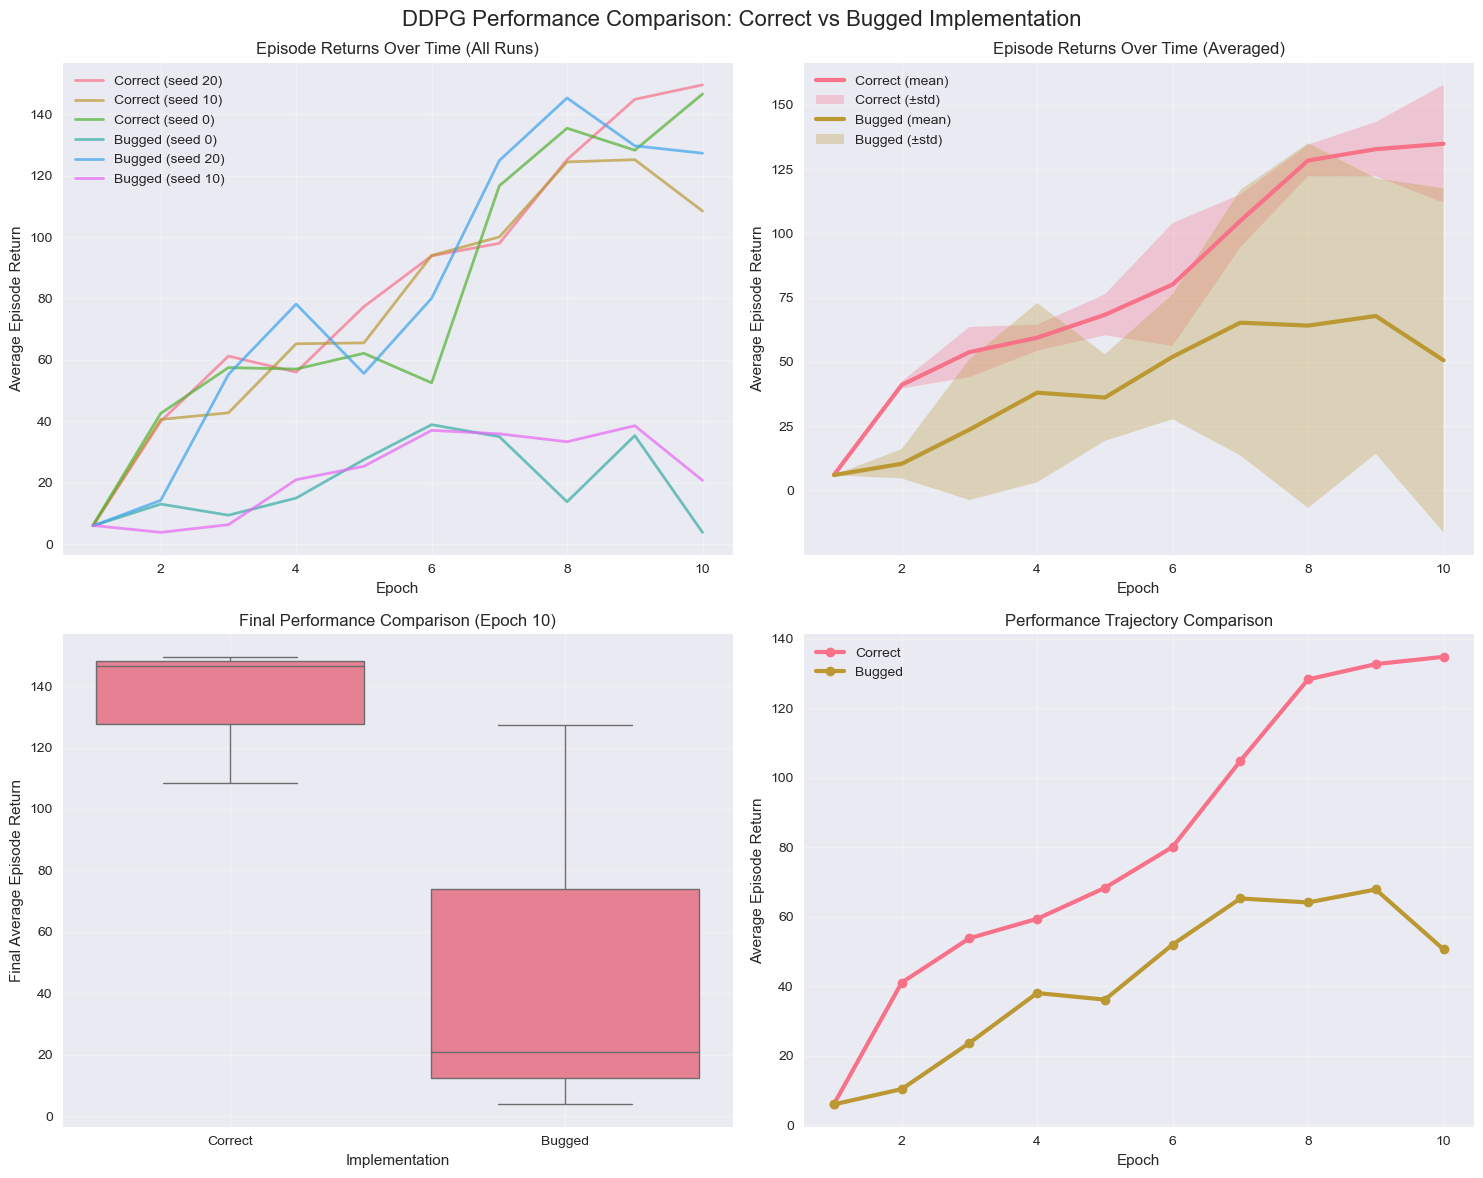


Final Performance Statistics (Epoch 10):
               mean        std         min        max
version                                              
Bugged    50.626340  66.923714    3.830303  127.28205
Correct  134.848253  22.904122  108.456520  149.52942


In [8]:
# Plot episode returns over time
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('DDPG Performance Comparison: Correct vs Bugged Implementation', fontsize=16)

# Episode returns - all runs
ax = axes[0, 0]
for version in ['Correct', 'Bugged']:
    version_data = all_data[all_data['version'] == version]
    for seed in version_data['seed'].unique():
        seed_data = version_data[version_data['seed'] == seed]
        ax.plot(seed_data['Epoch'], seed_data['AverageEpRet'],
                label=f'{version} (seed {seed})', alpha=0.7, linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Average Episode Return')
ax.set_title('Episode Returns Over Time (All Runs)')
ax.legend()
ax.grid(True, alpha=0.3)

# Episode returns - averaged across seeds
ax = axes[0, 1]
for version in ['Correct', 'Bugged']:
    version_data = all_data[all_data['version'] == version]
    mean_returns = version_data.groupby('Epoch')['AverageEpRet'].mean()
    std_returns = version_data.groupby('Epoch')['AverageEpRet'].std()
    epochs = mean_returns.index
    
    ax.plot(epochs, mean_returns, label=f'{version} (mean)', linewidth=3)
    ax.fill_between(epochs, mean_returns - std_returns, mean_returns + std_returns,
                    alpha=0.3, label=f'{version} (±std)')

ax.set_xlabel('Epoch')
ax.set_ylabel('Average Episode Return')
ax.set_title('Episode Returns Over Time (Averaged)')
ax.legend()
ax.grid(True, alpha=0.3)

# Final performance comparison
ax = axes[1, 0]
final_returns = all_data[all_data['Epoch'] == all_data['Epoch'].max()].copy()
sns.boxplot(data=final_returns, x='version', y='AverageEpRet', ax=ax)
ax.set_xlabel('Implementation')
ax.set_ylabel('Final Average Episode Return')
ax.set_title('Final Performance Comparison (Epoch 10)')
ax.grid(True, alpha=0.3)

# Performance trajectory
ax = axes[1, 1]
for version in ['Correct', 'Bugged']:
    version_data = all_data[all_data['version'] == version]
    mean_returns = version_data.groupby('Epoch')['AverageEpRet'].mean()
    ax.plot(mean_returns.index, mean_returns.values, label=version, linewidth=3, marker='o')

ax.set_xlabel('Epoch')
ax.set_ylabel('Average Episode Return')
ax.set_title('Performance Trajectory Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final performance stats
print("\nFinal Performance Statistics (Epoch 10):")
final_stats = final_returns.groupby('version')['AverageEpRet'].agg(['mean', 'std', 'min', 'max'])
print(final_stats)

## Q-Values and Loss Analysis

Now let's examine the Q-values and loss curves to understand the numerical stability issues.

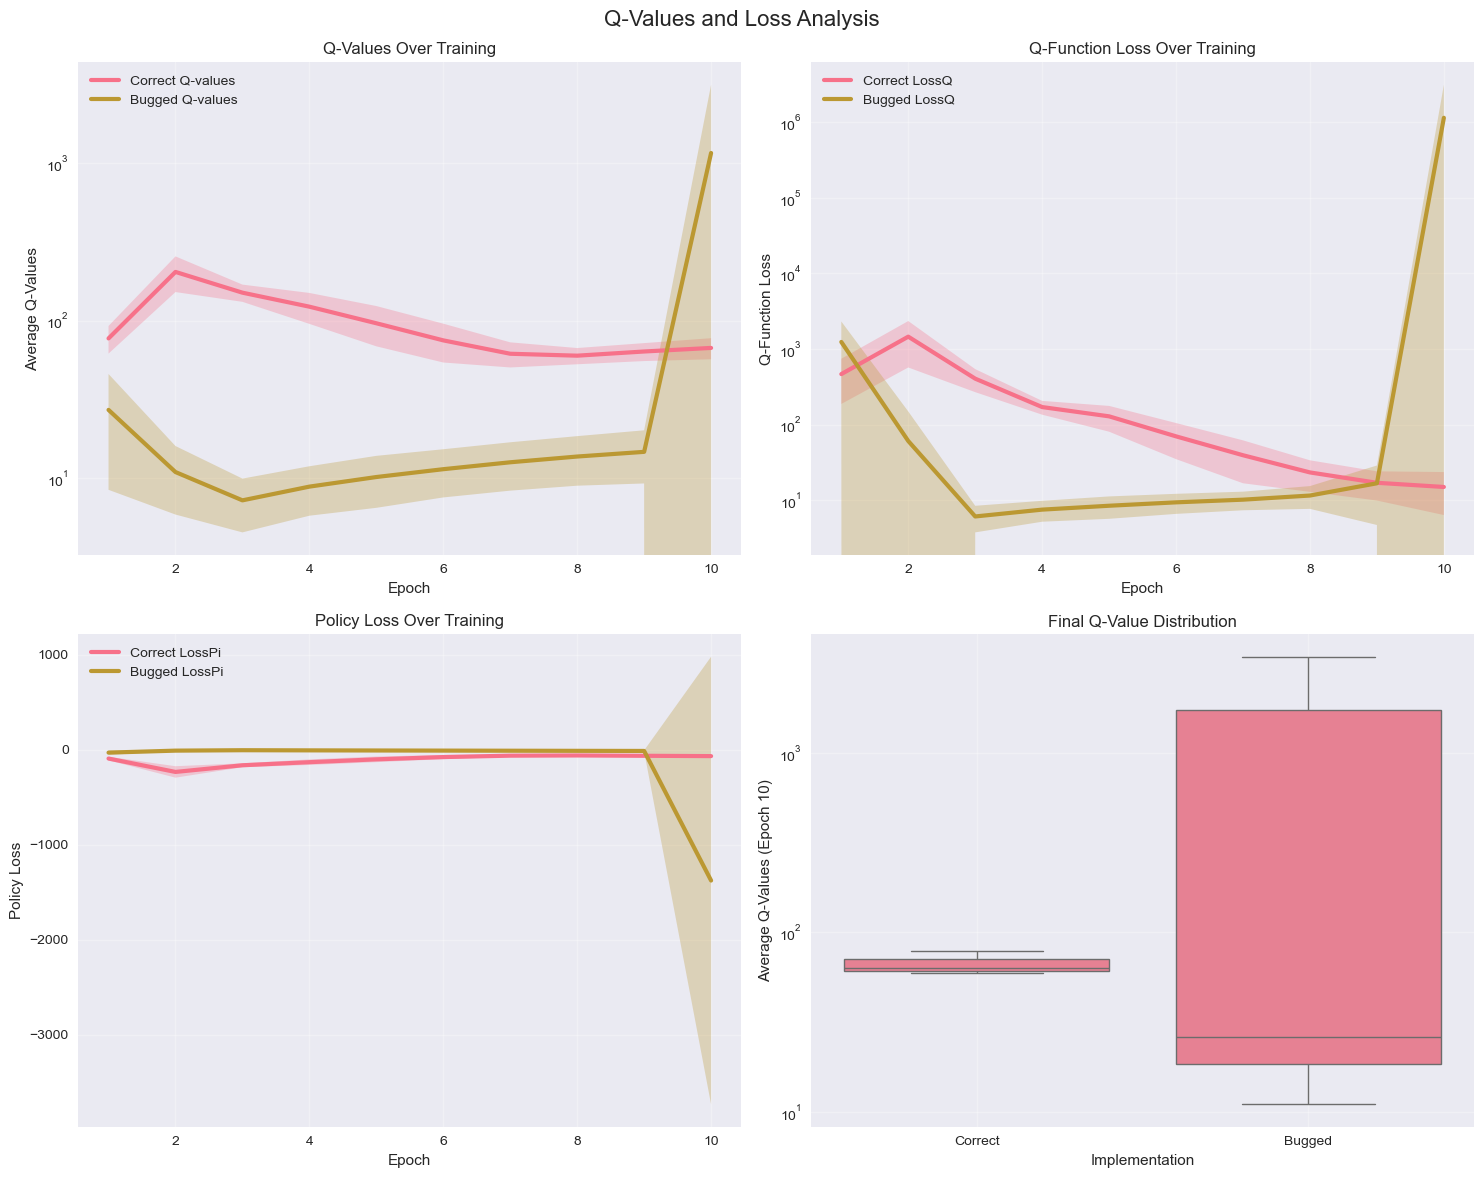

In [9]:
# Plot Q-values and losses
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Q-Values and Loss Analysis', fontsize=16)

# Q-values over time
ax = axes[0, 0]
for version in ['Correct', 'Bugged']:
    version_data = all_data[all_data['version'] == version]
    mean_q = version_data.groupby('Epoch')['AverageQVals'].mean()
    std_q = version_data.groupby('Epoch')['AverageQVals'].std()
    
    ax.plot(mean_q.index, mean_q.values, label=f'{version} Q-values', linewidth=3)
    ax.fill_between(mean_q.index, mean_q - std_q, mean_q + std_q, alpha=0.3)

ax.set_xlabel('Epoch')
ax.set_ylabel('Average Q-Values')
ax.set_title('Q-Values Over Training')
ax.legend()
ax.grid(True, alpha=0.3)
# Use log scale for Q-values to handle the explosion in bugged version
ax.set_yscale('log')

# Q-function loss over time
ax = axes[0, 1]
for version in ['Correct', 'Bugged']:
    version_data = all_data[all_data['version'] == version]
    mean_loss = version_data.groupby('Epoch')['LossQ'].mean()
    std_loss = version_data.groupby('Epoch')['LossQ'].std()
    
    ax.plot(mean_loss.index, mean_loss.values, label=f'{version} LossQ', linewidth=3)
    ax.fill_between(mean_loss.index, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3)

ax.set_xlabel('Epoch')
ax.set_ylabel('Q-Function Loss')
ax.set_title('Q-Function Loss Over Training')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Policy loss comparison
ax = axes[1, 0]
for version in ['Correct', 'Bugged']:
    version_data = all_data[all_data['version'] == version]
    mean_loss = version_data.groupby('Epoch')['LossPi'].mean()
    std_loss = version_data.groupby('Epoch')['LossPi'].std()
    
    ax.plot(mean_loss.index, mean_loss.values, label=f'{version} LossPi', linewidth=3)
    ax.fill_between(mean_loss.index, mean_loss - std_loss, mean_loss + std_loss, alpha=0.3)

ax.set_xlabel('Epoch')
ax.set_ylabel('Policy Loss')
ax.set_title('Policy Loss Over Training')
ax.legend()
ax.grid(True, alpha=0.3)

# Q-value distribution at final epoch
ax = axes[1, 1]
final_q = all_data[all_data['Epoch'] == all_data['Epoch'].max()].copy()
sns.boxplot(data=final_q, x='version', y='AverageQVals', ax=ax)
ax.set_xlabel('Implementation')
ax.set_ylabel('Average Q-Values (Epoch 10)')
ax.set_title('Final Q-Value Distribution')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## Detailed Bug Analysis

Let's examine the specific issues caused by the bug and understand why it leads to training instability.

In [10]:
# Analyze the divergence in the bugged version
print("Analyzing the bug's impact...")

# Find the epoch where the bugged version starts to diverge
bugged_final = all_data[(all_data['version'] == 'Bugged') & (all_data['Epoch'] == 10)]
correct_final = all_data[(all_data['version'] == 'Correct') & (all_data['Epoch'] == 10)]

print(f"\nFinal Epoch (10) Comparison:")
print(f"Correct - Average Return: {correct_final['AverageEpRet'].mean():.2f} ± {correct_final['AverageEpRet'].std():.2f}")
print(f"Bugged  - Average Return: {bugged_final['AverageEpRet'].mean():.2f} ± {bugged_final['AverageEpRet'].std():.2f}")
print(f"Correct - Average Q-Value: {correct_final['AverageQVals'].mean():.2f} ± {correct_final['AverageQVals'].std():.2f}")
print(f"Bugged  - Average Q-Value: {bugged_final['AverageQVals'].mean():.2f} ± {bugged_final['AverageQVals'].std():.2f}")
print(f"Correct - LossQ: {correct_final['LossQ'].mean():.2f} ± {correct_final['LossQ'].std():.2f}")
print(f"Bugged  - LossQ: {bugged_final['LossQ'].mean():.2f} ± {bugged_final['LossQ'].std():.2f}")

# Check for extreme values in bugged version
extreme_q = all_data[(all_data['version'] == 'Bugged') & (all_data['AverageQVals'] > 1000)]
if len(extreme_q) > 0:
    print(f"\nExtreme Q-values detected in bugged version:")
    print(f"Number of extreme cases: {len(extreme_q)}")
    print(f"Max Q-value: {extreme_q['AverageQVals'].max():.0f}")
    print(f"Corresponding LossQ: {extreme_q['LossQ'].max():.0f}")

# Calculate performance degradation
performance_drop = (correct_final['AverageEpRet'].mean() - bugged_final['AverageEpRet'].mean()) / correct_final['AverageEpRet'].mean() * 100
print(f"\nPerformance degradation: {performance_drop:.1f}%")

Analyzing the bug's impact...

Final Epoch (10) Comparison:
Correct - Average Return: 134.85 ± 22.90
Bugged  - Average Return: 50.63 ± 66.92
Correct - Average Q-Value: 67.11 ± 10.23
Bugged  - Average Q-Value: 1153.39 ± 1965.50
Correct - LossQ: 14.96 ± 8.60
Bugged  - LossQ: 1147001.71 ± 1986591.34

Extreme Q-values detected in bugged version:
Number of extreme cases: 1
Max Q-value: 3423
Corresponding LossQ: 3440920

Performance degradation: 62.5%


## Summary and Conclusions

Based on our analysis, we can draw several key conclusions about the impact of this seemingly minor bug:

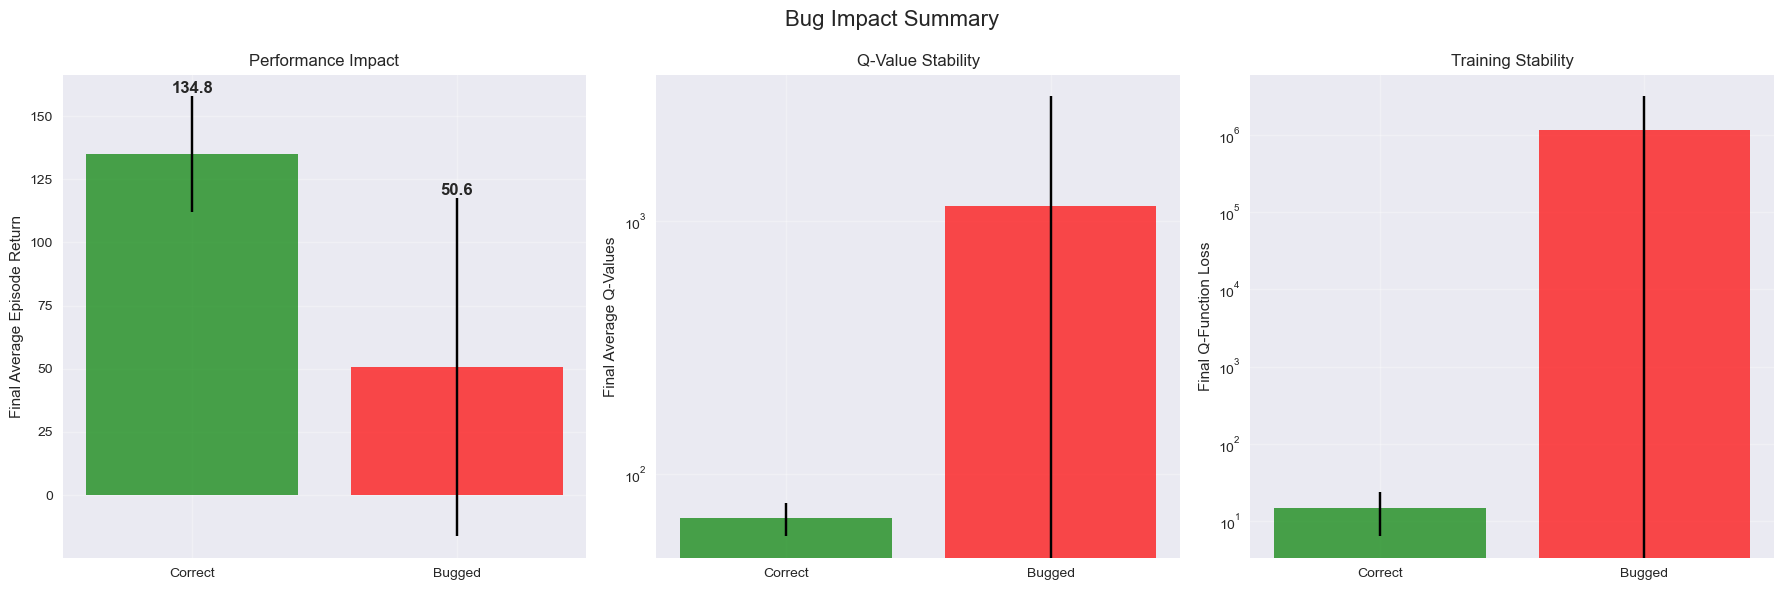


EXERCISE 2.2 ANALYSIS SUMMARY

The Bug:
- Missing torch.squeeze(q, -1) in Q-function forward pass
- Causes shape mismatch: Q-values have shape [batch_size, 1] instead of [batch_size]

Impact:
- Performance degradation: 62.5%
- Q-values explode by orders of magnitude
- Training becomes numerically unstable
- Loss gradients become incorrect due to shape mismatch

Why it matters:
- Shape consistency is critical in PyTorch loss computations
- Extra dimensions can cause broadcasting issues
- Gradient flow becomes unpredictable

The fix:
- Always ensure output tensors have expected shapes
- Use torch.squeeze() to remove singleton dimensions
- Test with different batch sizes to catch shape issues


In [11]:
# Create a summary visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Bug Impact Summary', fontsize=16)

# Performance comparison
ax = axes[0]
versions = ['Correct', 'Bugged']
means = [correct_final['AverageEpRet'].mean(), bugged_final['AverageEpRet'].mean()]
stds = [correct_final['AverageEpRet'].std(), bugged_final['AverageEpRet'].std()]

bars = ax.bar(versions, means, yerr=stds, capsize=10, alpha=0.7, color=['green', 'red'])
ax.set_ylabel('Final Average Episode Return')
ax.set_title('Performance Impact')
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + stds[versions.index(versions[list(bars).index(bar)])],
            f'{mean:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Q-value explosion
ax = axes[1]
q_means = [correct_final['AverageQVals'].mean(), bugged_final['AverageQVals'].mean()]
q_stds = [correct_final['AverageQVals'].std(), bugged_final['AverageQVals'].std()]

bars = ax.bar(versions, q_means, yerr=q_stds, capsize=10, alpha=0.7, color=['green', 'red'])
ax.set_ylabel('Final Average Q-Values')
ax.set_title('Q-Value Stability')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Loss comparison
ax = axes[2]
loss_means = [correct_final['LossQ'].mean(), bugged_final['LossQ'].mean()]
loss_stds = [correct_final['LossQ'].std(), bugged_final['LossQ'].std()]

bars = ax.bar(versions, loss_means, yerr=loss_stds, capsize=10, alpha=0.7, color=['green', 'red'])
ax.set_ylabel('Final Q-Function Loss')
ax.set_title('Training Stability')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EXERCISE 2.2 ANALYSIS SUMMARY")
print("="*60)
print("\nThe Bug:")
print("- Missing torch.squeeze(q, -1) in Q-function forward pass")
print("- Causes shape mismatch: Q-values have shape [batch_size, 1] instead of [batch_size]")
print("\nImpact:")
print(f"- Performance degradation: {performance_drop:.1f}%")
print("- Q-values explode by orders of magnitude")
print("- Training becomes numerically unstable")
print("- Loss gradients become incorrect due to shape mismatch")
print("\nWhy it matters:")
print("- Shape consistency is critical in PyTorch loss computations")
print("- Extra dimensions can cause broadcasting issues")
print("- Gradient flow becomes unpredictable")
print("\nThe fix:")
print("- Always ensure output tensors have expected shapes")
print("- Use torch.squeeze() to remove singleton dimensions")
print("- Test with different batch sizes to catch shape issues")